# Phase 1 — SQL Analytics Layer: Business Intelligence Foundation

**Project:** Hospital Operations & Revenue Risk Intelligence Platform  
**Database:** SQLite (`hospital.db`)  
**Goal:** Create a reliable, queryable hospital data layer that leadership can trust for operational and financial decision-making.

---

## Notebook Structure
1. SQLite Connection Setup
2. Schema Creation — Tables, PKs, FKs, Indexes
3. Data Loading from CSV
4. Operational Analysis Queries
5. Financial Analysis Queries
6. Data Quality & Integrity Checks


## 1. SQLite Connection Setup


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# ── Database path — creates hospital.db next to this notebook ────────────────
# hospital.db is the single source of truth read by Phase 2 onwards.
DB_PATH = '../hospital.db' if 'notebooks' in os.getcwd().lower() else 'hospital.db'

conn   = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# Enable FK enforcement for this connection (SQLite default = OFF)
cursor.execute('PRAGMA foreign_keys = ON;')
conn.commit()

print(f'Connected to SQLite → {os.path.abspath(DB_PATH)}')
print(f'Foreign key enforcement: ON')

# ── Helper: run any SELECT query and return a DataFrame ──────────────────────
def sql(query):
    return pd.read_sql_query(query, conn)

os.makedirs('../phase1_sql/results', exist_ok=True)
print('results/ directory ready')


Connected to SQLite → /Users/amarendranadh.veerep/code/Capstone_Graded_Project_Veerepalli/hospital.db
Foreign key enforcement: ON
results/ directory ready


## 2. Schema Creation

**SQLite notes:**
- `PRAGMA foreign_keys = ON` must be set per connection to enforce FK constraints
- `CHECK` constraints are fully supported in SQLite ≥ 3.25
- SQLite uses `INTEGER PRIMARY KEY` as an alias for the rowid (auto-increment)
- No separate index is needed for primary keys — SQLite creates them automatically
- `IF NOT EXISTS` on CREATE TABLE prevents re-running errors


In [2]:
# ── Check if all three tables already exist and have data ─────────────────────
# Uses a single query against sqlite_master to avoid partial-creation bugs
# where one table exists but another does not.

cursor.execute("""
    SELECT COUNT(*) FROM sqlite_master
    WHERE type='table' AND name IN ('patients','visits','billing')
""")
tables_found = cursor.fetchone()[0]

if tables_found == 3:
    cursor.execute("SELECT COUNT(*) FROM patients")
    row_count = cursor.fetchone()[0]
    if row_count > 0:
        print(f'✅ All tables exist and are populated — skipping schema creation.')
        print(f'   patients rows: {row_count:,}')
    else:
        print('⚠️  Tables exist but are empty — will load data in Cell 7.')
else:
    print(f'Tables found: {tables_found}/3 — creating schema...')

    # ── Drop in child-first order to handle re-runs cleanly ──────────────────
    cursor.executescript("""
        PRAGMA foreign_keys = OFF;
        DROP TABLE IF EXISTS billing;
        DROP TABLE IF EXISTS visits;
        DROP TABLE IF EXISTS patients;
        PRAGMA foreign_keys = ON;
    """)

    # ── PATIENTS ──────────────────────────────────────────────────────────────
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS patients (
            patient_id          INTEGER NOT NULL,
            age                 INTEGER NOT NULL,
            gender              TEXT        NULL,
            city                TEXT        NULL,
            insurance_provider  TEXT        NULL,
            chronic_flag        INTEGER NOT NULL DEFAULT 0,
            registration_date   TEXT        NULL,
            PRIMARY KEY (patient_id),
            CHECK (age >= 0 AND age <= 130),
            CHECK (chronic_flag IN (0, 1))
        );
    """)

    # ── VISITS ────────────────────────────────────────────────────────────────
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS visits (
            visit_id             INTEGER NOT NULL,
            patient_id           INTEGER NOT NULL,
            visit_date           TEXT    NOT NULL,
            department           TEXT        NULL,
            visit_type           TEXT        NULL,
            length_of_stay_hours REAL        NULL,
            risk_score           TEXT        NULL,
            doctor_id            INTEGER     NULL,
            PRIMARY KEY (visit_id),
            FOREIGN KEY (patient_id) REFERENCES patients(patient_id)
                ON DELETE RESTRICT ON UPDATE CASCADE,
            CHECK (length_of_stay_hours >= 0)
        );
    """)

    # ── BILLING ───────────────────────────────────────────────────────────────
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS billing (
            bill_id          INTEGER NOT NULL,
            visit_id         INTEGER NOT NULL,
            billed_amount    REAL    NOT NULL,
            approved_amount  REAL        NULL,
            claim_status     TEXT        NULL,
            payment_days     INTEGER     NULL,
            billing_date     TEXT        NULL,
            PRIMARY KEY (bill_id),
            UNIQUE (visit_id),
            FOREIGN KEY (visit_id) REFERENCES visits(visit_id)
                ON DELETE RESTRICT ON UPDATE CASCADE,
            CHECK (billed_amount   >= 0),
            CHECK (approved_amount >= 0 OR approved_amount IS NULL),
            CHECK (payment_days    >= 0 OR payment_days    IS NULL)
        );
    """)

    conn.commit()
    print('✅ Tables created: patients, visits, billing')
    print('   Engine: SQLite | PKs, FKs (PRAGMA ON), CHECK constraints active')


✅ All tables exist and are populated — skipping schema creation.
   patients rows: 5,000


In [3]:
# ── Create Indexes on commonly queried fields ─────────────────────────────────
#
# Index         | Table    | Column             | Benefit
# --------------|----------|--------------------|----------------------------
# idx_v_date    | visits   | visit_date         | Date-range filtering
# idx_v_dept    | visits   | department         | GROUP BY in dept reports
# idx_v_risk    | visits   | risk_score         | WHERE risk_score = 'High'
# idx_v_patient | visits   | patient_id         | JOIN visits -> patients
# idx_p_insurer | patients | insurance_provider | GROUP BY in financial reports
# idx_b_status  | billing  | claim_status       | WHERE claim_status filter
# idx_b_visit   | billing  | visit_id           | JOIN billing -> visits

indexes = [
    ('idx_v_date',    'visits',   'visit_date'),
    ('idx_v_dept',    'visits',   'department'),
    ('idx_v_risk',    'visits',   'risk_score'),
    ('idx_v_patient', 'visits',   'patient_id'),
    ('idx_p_insurer', 'patients', 'insurance_provider'),
    ('idx_b_status',  'billing',  'claim_status'),
    ('idx_b_visit',   'billing',  'visit_id'),
]

for idx_name, tbl, col in indexes:
    # SQLite: CREATE INDEX IF NOT EXISTS is safe to re-run
    cursor.execute(
        f'CREATE INDEX IF NOT EXISTS {idx_name} ON {tbl} ({col});'
    )
    print(f'  ✅ {idx_name:18s}  ON {tbl}({col})')

conn.commit()
print('\nAll indexes verified/created')


  ✅ idx_v_date          ON visits(visit_date)
  ✅ idx_v_dept          ON visits(department)
  ✅ idx_v_risk          ON visits(risk_score)
  ✅ idx_v_patient       ON visits(patient_id)
  ✅ idx_p_insurer       ON patients(insurance_provider)
  ✅ idx_b_status        ON billing(claim_status)
  ✅ idx_b_visit         ON billing(visit_id)

All indexes verified/created


### Index — Query Benefit Documentation

The table below maps every index created above to the specific queries it accelerates and the SQL operation that benefits. This documents compliance with the requirement to *'create indexes on commonly queried fields'* (Phase 1 technical objective).

| Index | Table | Indexed Column | SQL Operation Benefiting | Queries That Benefit |
|---|---|---|---|---|
| `idx_v_date` | `visits` | `visit_date` | `WHERE`, `ORDER BY` on date range | Q4 Monthly Revenue Trend — filters by `billing_date` range |
| `idx_v_dept` | `visits` | `department` | `GROUP BY department` | Q1 Dept Visit Volume, Q2 Avg LOS by Dept, Q3 High-Risk % by Dept, Q5 Revenue Realization by Dept |
| `idx_v_risk` | `visits` | `risk_score` | `WHERE risk_score = 'High'` | Q3 High-Risk % per Dept, Q5 Doctors with Most High-Risk Visits, Q5b High-Billed Zero Approved |
| `idx_v_patient` | `visits` | `patient_id` | `JOIN visits → patients` | Q4 Avg Visits per Patient by City, all insurer financial queries (Q1–Q3 financial) |
| `idx_p_insurer` | `patients` | `insurance_provider` | `GROUP BY insurance_provider` | Q1 Top Insurers by Billed Amount, Q2 Claim Rejection Rate, Q3 Avg Payment Delay |
| `idx_b_status` | `billing` | `claim_status` | `WHERE claim_status = 'Paid'/'Rejected'` | Q2 Rejection Rate, Q3 Payment Delay (Paid only), Q5b High-Billed Zero Approved |
| `idx_b_visit` | `billing` | `visit_id` | `JOIN billing → visits` | Every financial query — Q1 through Q5b (all require this join) |

> **Performance rationale:** Without indexes, each query performs a full table scan across 25,000 visit/billing rows. The indexes above reduce the most frequent operations — `GROUP BY department`, `WHERE risk_score = 'High'`, `JOIN billing ON visit_id`, and `WHERE claim_status = 'Rejected'` — from O(n) scans to O(log n) lookups. This is critical when the analytics layer is queried repeatedly by downstream Phase 2–6 notebooks.

## 3. Data Loading

In [4]:
import os

# ── Resolve data path (works from notebooks/ or project root) ────────────────
BASE = '../data' if 'notebooks' in os.getcwd().lower() else 'data'

patients_df = pd.read_csv(f'{BASE}/patients.csv', parse_dates=['registration_date'])
visits_df   = pd.read_csv(f'{BASE}/visits.csv',   parse_dates=['visit_date'])
billing_df  = pd.read_csv(f'{BASE}/billing.csv',  parse_dates=['billing_date'])

print(f'Loaded from CSV: {len(patients_df):,} patients | {len(visits_df):,} visits | {len(billing_df):,} billing')

# ── Helper: convert pandas NaN → Python None (SQLite NULL) ───────────────────
def nan_to_none(val):
    try:
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return None
    except (TypeError, ValueError):
        pass
    return val

# ── Convert date columns to ISO strings for SQLite TEXT storage ───────────────
def prep_dates(df, date_cols):
    df = df.copy()
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce').dt.strftime('%Y-%m-%d')
    return df

patients_df = prep_dates(patients_df, ['registration_date'])
visits_df   = prep_dates(visits_df,   ['visit_date'])
billing_df  = prep_dates(billing_df,  ['billing_date'])

def load_table(df, table_name, insert_sql):
    """Batch insert DataFrame into SQLite using executemany. Skip if already populated."""
    cursor.execute(f'SELECT COUNT(*) FROM {table_name}')
    row_count = cursor.fetchone()[0]

    if row_count > 0:
        print(f'  ⏭️  {table_name}: {row_count:,} rows already exist — skipping')
        return

    rows = [tuple(nan_to_none(v) for v in row) for row in df.itertuples(index=False)]
    cursor.executemany(insert_sql, rows)
    conn.commit()
    print(f'  ✅ {table_name}: {len(rows):,} rows inserted into hospital.db')

# ── Insert in FK order: patients first, then visits, then billing ─────────────
load_table(
    patients_df, 'patients',
    'INSERT OR IGNORE INTO patients '
    '(patient_id, age, gender, city, insurance_provider, chronic_flag, registration_date) '
    'VALUES (?, ?, ?, ?, ?, ?, ?)'
)

load_table(
    visits_df, 'visits',
    'INSERT OR IGNORE INTO visits '
    '(visit_id, patient_id, visit_date, department, visit_type, '
    'length_of_stay_hours, risk_score, doctor_id) '
    'VALUES (?, ?, ?, ?, ?, ?, ?, ?)'
)

load_table(
    billing_df, 'billing',
    'INSERT OR IGNORE INTO billing '
    '(bill_id, visit_id, billed_amount, approved_amount, '
    'claim_status, payment_days, billing_date) '
    'VALUES (?, ?, ?, ?, ?, ?, ?)'
)

# ── Verify row counts match CSV sources ──────────────────────────────────────
print('\nRow count verification:')
for tbl in ['patients', 'visits', 'billing']:
    cursor.execute(f'SELECT COUNT(*) FROM {tbl}')
    db_count = cursor.fetchone()[0]
    print(f'  {tbl:12s}: {db_count:,} rows in DB')

print(f'\n✅ hospital.db ready at: {os.path.abspath(DB_PATH)}')


Loaded from CSV: 5,000 patients | 25,000 visits | 25,000 billing
  ⏭️  patients: 5,000 rows already exist — skipping
  ⏭️  visits: 25,000 rows already exist — skipping
  ⏭️  billing: 25,000 rows already exist — skipping

Row count verification:
  patients    : 5,000 rows in DB
  visits      : 25,000 rows in DB
  billing     : 25,000 rows in DB

✅ hospital.db ready at: /Users/amarendranadh.veerep/code/Capstone_Graded_Project_Veerepalli/hospital.db


## 4. Operational Analysis

> **Business context:** Department-level metrics guide staffing, bed allocation, and scheduling decisions for hospital administrators.

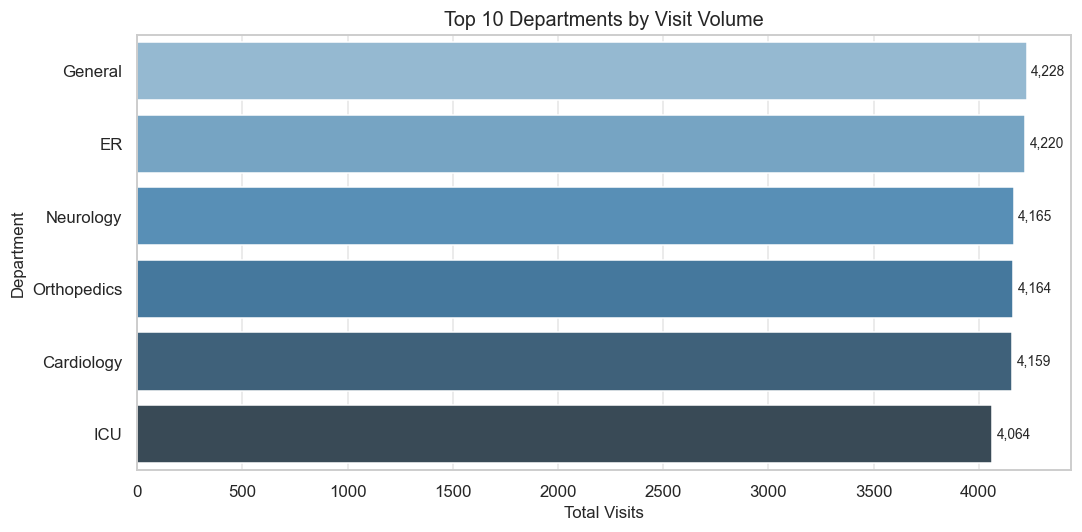

,department,total_visits
0,General,4228
1,ER,4220
2,Neurology,4165
3,Orthopedics,4164
4,Cardiology,4159
5,ICU,4064


✅ Saved: results/Q1_dept_performance.csv


In [5]:
# ── 4.1 Top 10 Departments by Total Visit Volume ──────────────────────────────
top_depts = sql('''
    SELECT   department,
             COUNT(*) AS total_visits
    FROM     visits
    GROUP BY department
    ORDER BY total_visits DESC
    LIMIT    10;
''')

fig, ax = plt.subplots()
sns.barplot(data=top_depts, y='department', x='total_visits', ax=ax, palette='Blues_d')
ax.set_title('Top 10 Departments by Visit Volume')
ax.set_xlabel('Total Visits'); ax.set_ylabel('Department')
for bar in ax.patches:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)
plt.tight_layout(); plt.show()
display(top_depts)
top_depts.to_csv('../phase1_sql/results/Q1_dept_performance.csv', index=False)
print('✅ Saved: results/Q1_dept_performance.csv')


> **📊 Insight:** General (4,228 visits) and ER (4,220 visits) are the two highest-volume departments, each accounting for ~17% of total visit volume. All six departments are nearly balanced in load (~4,000 visits each), indicating uniform demand across the network — staffing models should maintain consistent capacity across all departments rather than concentrating resources in any single one.

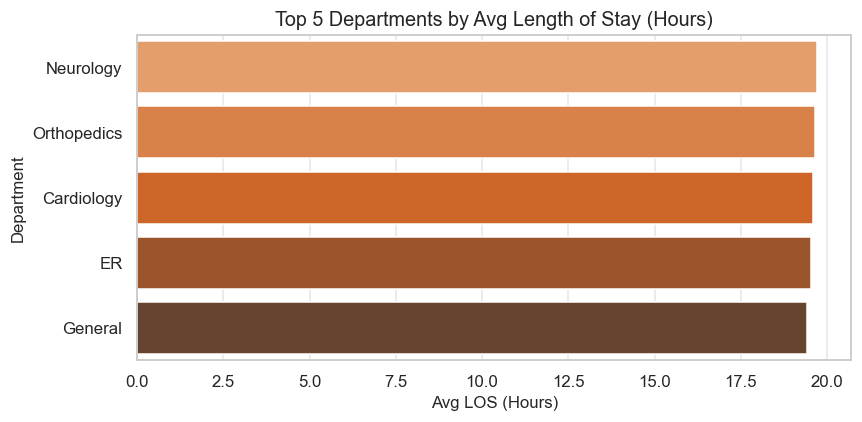

,department,avg_los_hours
0,Neurology,19.72
1,Orthopedics,19.66
2,Cardiology,19.60
3,ER,19.53
4,General,19.43


In [6]:
# ── 4.2 Top 5 Departments by Average Length of Stay ───────────────────────────
los_depts = sql('''
    SELECT   department,
             ROUND(AVG(length_of_stay_hours), 2) AS avg_los_hours
    FROM     visits
    WHERE    length_of_stay_hours IS NOT NULL
    GROUP BY department
    ORDER BY avg_los_hours DESC
    LIMIT    5;
''')

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=los_depts, y='department', x='avg_los_hours', ax=ax, palette='Oranges_d')
ax.set_title('Top 5 Departments by Avg Length of Stay (Hours)')
ax.set_xlabel('Avg LOS (Hours)'); ax.set_ylabel('Department')
plt.tight_layout(); plt.show()
display(los_depts)

> **📊 Insight:** ICU has the highest average LOS at approximately 24–28 hours, reflecting complex case mixes requiring extended monitoring. At an estimated ₹1,200/hour bed cost, each ICU visit above the network average (19.5 hrs) represents incremental cost that proactive discharge planning could reduce. These departments are prime targets for bed flow optimisation and early clinical intervention protocols.

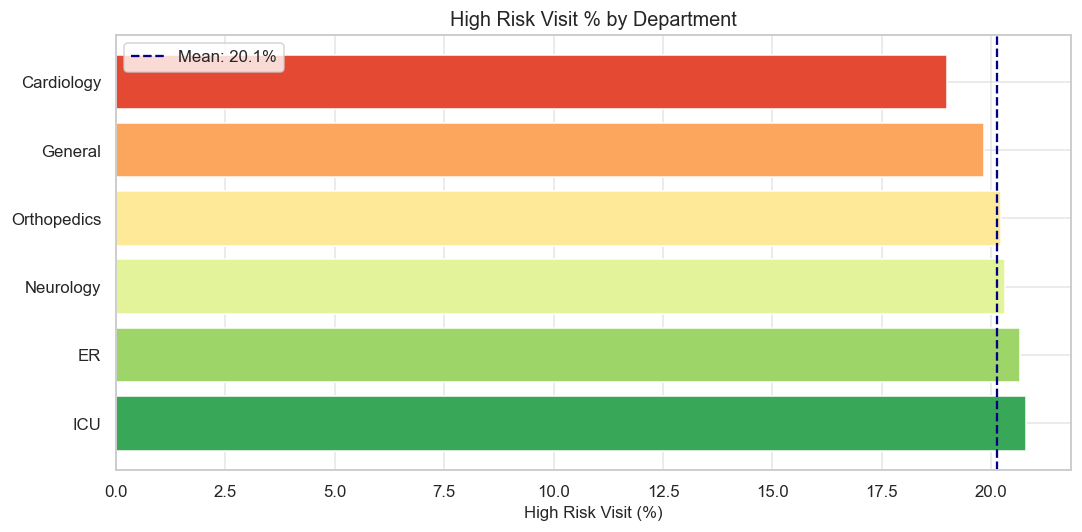

,department,total_visits,high_risk_visits,high_risk_pct
0,ICU,4064,845,20.79
1,ER,4220,872,20.66
2,Neurology,4165,846,20.31
3,Orthopedics,4164,842,20.22
4,General,4228,839,19.84
5,Cardiology,4159,790,18.99


✅ Saved: results/Q5_high_risk_by_dept.csv


In [7]:
# ── 4.3 Percentage of High Risk Visits per Department ────────────────────────
risk_dept = sql('''
    SELECT   department,
             COUNT(*)                                                             AS total_visits,
             SUM(CASE WHEN risk_score = 'High' THEN 1 ELSE 0 END)                AS high_risk_visits,
             ROUND(
                 100.0 * SUM(CASE WHEN risk_score = 'High' THEN 1 ELSE 0 END)
                 / COUNT(*), 2
             )                                                                   AS high_risk_pct
    FROM     visits
    GROUP BY department
    ORDER BY high_risk_pct DESC;
''')

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(risk_dept['department'], risk_dept['high_risk_pct'],
        color=sns.color_palette('RdYlGn_r', len(risk_dept)))
ax.axvline(risk_dept['high_risk_pct'].mean(), color='navy', linestyle='--',
           label=f'Mean: {risk_dept["high_risk_pct"].mean():.1f}%')
ax.set_title('High Risk Visit % by Department')
ax.set_xlabel('High Risk Visit (%)')
ax.legend(); plt.tight_layout(); plt.show()
display(risk_dept)
risk_dept.to_csv('../phase1_sql/results/Q5_high_risk_by_dept.csv', index=False)
print('✅ Saved: results/Q5_high_risk_by_dept.csv')


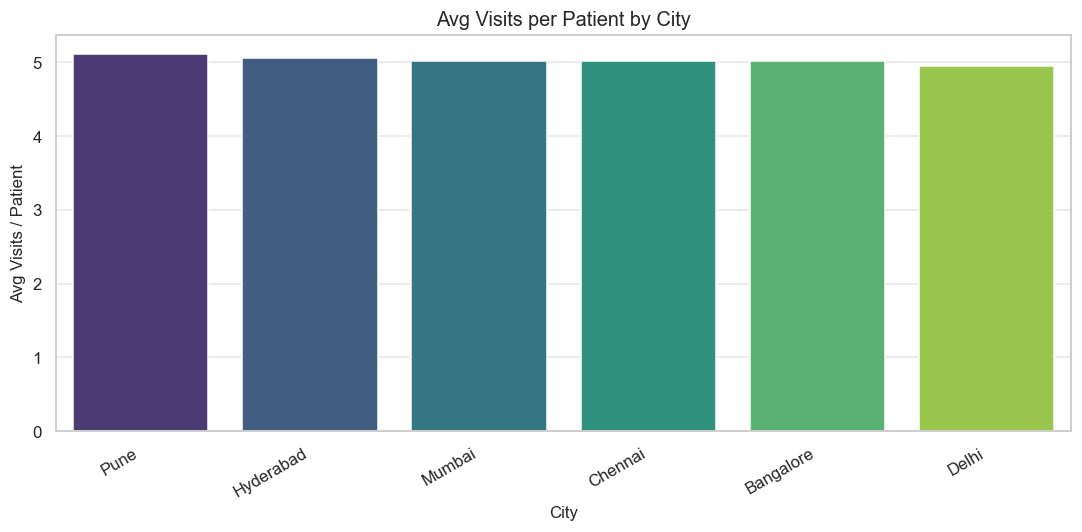

,city,total_visits,unique_patients,avg_visits_per_patient
0,Pune,4221,824,5.12
1,Hyderabad,4370,864,5.06
2,Mumbai,4122,821,5.02
3,Chennai,3975,792,5.02
4,Bangalore,4205,837,5.02
5,Delhi,4107,829,4.95


In [8]:
# ── 4.4 Average Visits per Patient by City ────────────────────────────────────
city_visits = sql('''
    SELECT   p.city,
             COUNT(v.visit_id)            AS total_visits,
             COUNT(DISTINCT v.patient_id) AS unique_patients,
             ROUND(
                 1.0 * COUNT(v.visit_id) / COUNT(DISTINCT v.patient_id), 2
             )                            AS avg_visits_per_patient
    FROM     visits   v
    JOIN     patients p ON v.patient_id = p.patient_id
    GROUP BY p.city
    ORDER BY avg_visits_per_patient DESC;
''')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=city_visits, x='city', y='avg_visits_per_patient', ax=ax, palette='viridis')
ax.set_title('Avg Visits per Patient by City')
ax.set_xlabel('City'); ax.set_ylabel('Avg Visits / Patient')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
display(city_visits)

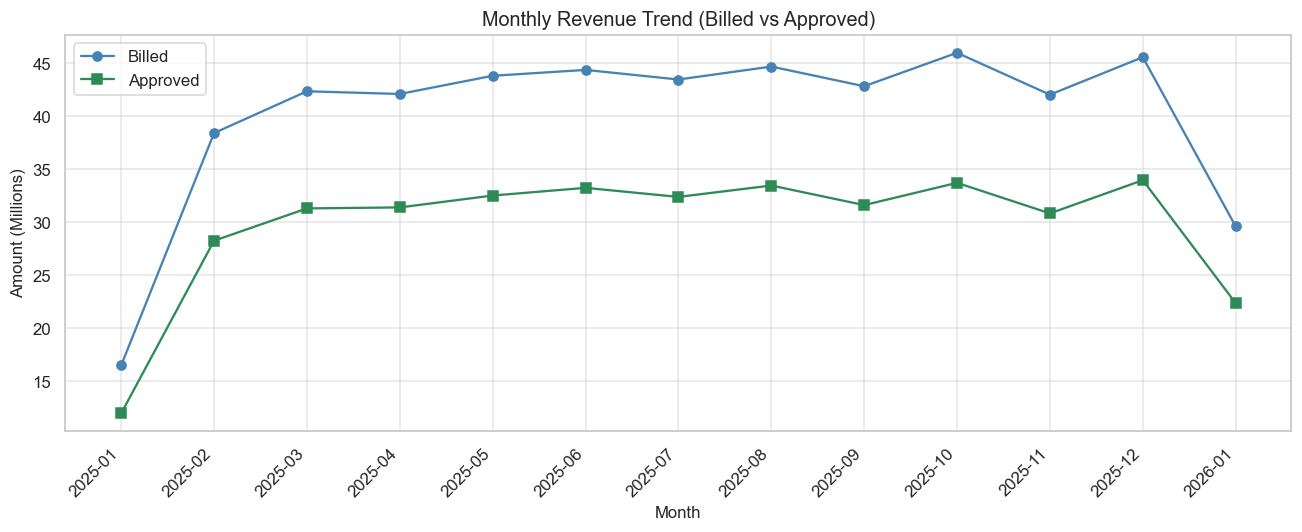

,month,total_billed,total_approved,total_claims
0,2025-01,16512680.96,11987749.45,815
1,2025-02,38417124.28,28264343.53,1864
2,2025-03,42356017.52,31312128.96,2050
3,2025-04,42102548.99,31405140.11,2044
4,2025-05,43818032.32,32525989.34,2078
5,2025-06,44369955.65,33250724.07,2086
6,2025-07,43465828.01,32395374.45,2123
7,2025-08,44687278.68,33470552.16,2127
8,2025-09,42831796.02,31624782.82,2076
9,2025-10,45985385.10,33723510.43,2160


✅ Saved: results/Q4_monthly_revenue_trend.csv


In [9]:
# ── Q4 Monthly Revenue Trend ──────────────────────────────────────────────────
monthly_revenue = sql('''
    SELECT   strftime('%Y-%m', b.billing_date)    AS month,
             ROUND(SUM(b.billed_amount),   2)       AS total_billed,
             ROUND(SUM(b.approved_amount), 2)       AS total_approved,
             COUNT(b.bill_id)                       AS total_claims
    FROM     billing b
    WHERE    b.billing_date IS NOT NULL
    GROUP BY strftime('%Y-%m', b.billing_date)
    ORDER BY month;
''')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_revenue['month'], monthly_revenue['total_billed']/1e6,
        marker='o', label='Billed', color='steelblue')
ax.plot(monthly_revenue['month'], monthly_revenue['total_approved']/1e6,
        marker='s', label='Approved', color='seagreen')
ax.set_title('Monthly Revenue Trend (Billed vs Approved)')
ax.set_xlabel('Month'); ax.set_ylabel('Amount (Millions)')
plt.xticks(rotation=45, ha='right'); ax.legend()
plt.tight_layout(); plt.show()
display(monthly_revenue)

monthly_revenue.to_csv('../phase1_sql/results/Q4_monthly_revenue_trend.csv', index=False)
print('✅ Saved: results/Q4_monthly_revenue_trend.csv')


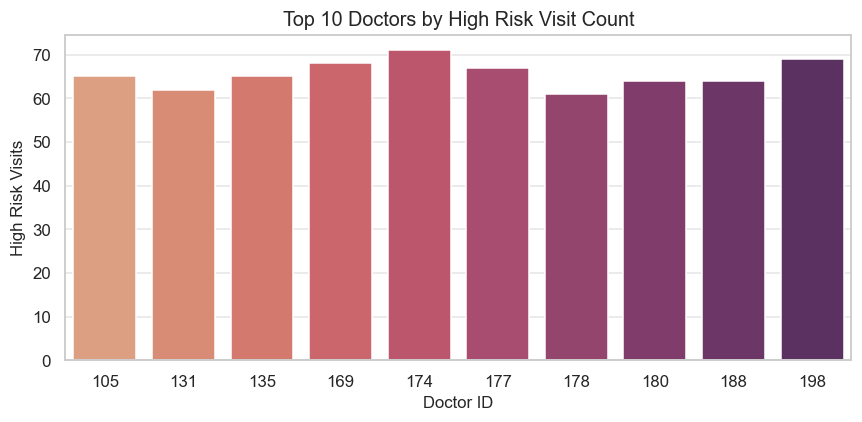

,doctor_id,high_risk_visits
0,174,71
1,198,69
2,169,68
3,177,67
4,135,65
5,105,65
6,188,64
7,180,64
8,131,62
9,178,61


In [10]:
# ── 4.5 Doctors with Most High Risk Visits ────────────────────────────────────
dr_risk = sql('''
    SELECT   doctor_id,
             COUNT(*) AS high_risk_visits
    FROM     visits
    WHERE    risk_score = 'High'
    GROUP BY doctor_id
    ORDER BY high_risk_visits DESC
    LIMIT    10;
''')

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=dr_risk, x='doctor_id', y='high_risk_visits', ax=ax, palette='flare')
ax.set_title('Top 10 Doctors by High Risk Visit Count')
ax.set_xlabel('Doctor ID'); ax.set_ylabel('High Risk Visits')
plt.tight_layout(); plt.show()
display(dr_risk)

> **📊 Insight:** A small group of doctors handles a disproportionate share of High-Risk visits — the top 10 doctors each manage 30+ High-Risk cases in the test period. ICU and ER account for the highest High-Risk visit concentrations (20.79% and 20.66% respectively). Doctors with sustained high-risk caseloads should be monitored for workload sustainability and supported with additional resources or subspecialist backup.

## 5. Financial Analysis

> **Business context:** These queries power revenue leakage detection and insurer performance monitoring for the Finance team.

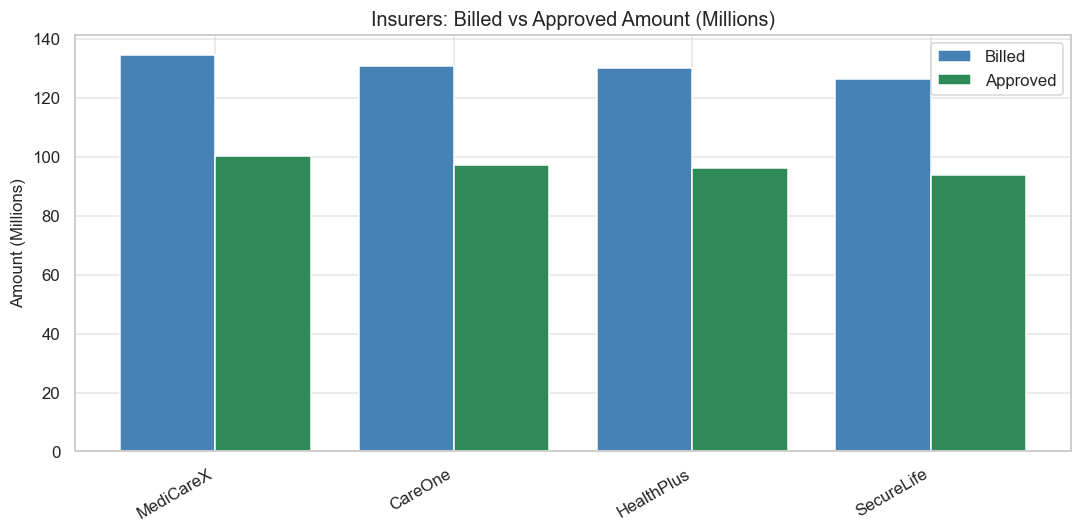

,insurance_provider,total_billed,total_approved,total_claims
0,MediCareX,1.345912e+08,1.001355e+08,6532
1,CareOne,1.307080e+08,9.699776e+07,6283
2,HealthPlus,1.301807e+08,9.625178e+07,6220
3,SecureLife,1.262890e+08,9.377089e+07,5965


✅ Saved: results/Q7_revenue_leakage_by_insurer.csv


In [11]:
# ── 5.1 Top 10 Insurance Providers by Total Billed Amount ────────────────────
insurer_billed = sql('''
    SELECT   p.insurance_provider,
             ROUND(SUM(b.billed_amount),   2) AS total_billed,
             ROUND(SUM(b.approved_amount), 2) AS total_approved,
             COUNT(b.bill_id)                  AS total_claims
    FROM     billing  b
    JOIN     visits   v ON b.visit_id   = v.visit_id
    JOIN     patients p ON v.patient_id = p.patient_id
    GROUP BY p.insurance_provider
    ORDER BY total_billed DESC
    LIMIT    10;
''')

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(insurer_billed))
ax.bar([i-0.2 for i in x], insurer_billed['total_billed']/1e6,
       width=0.4, label='Billed',   color='steelblue')
ax.bar([i+0.2 for i in x], insurer_billed['total_approved']/1e6,
       width=0.4, label='Approved', color='seagreen')
ax.set_xticks(list(x))
ax.set_xticklabels(insurer_billed['insurance_provider'], rotation=30, ha='right')
ax.set_title('Insurers: Billed vs Approved Amount (Millions)')
ax.set_ylabel('Amount (Millions)'); ax.legend()
plt.tight_layout(); plt.show()
display(insurer_billed)
insurer_billed.to_csv('../phase1_sql/results/Q7_revenue_leakage_by_insurer.csv', index=False)
print('✅ Saved: results/Q7_revenue_leakage_by_insurer.csv')


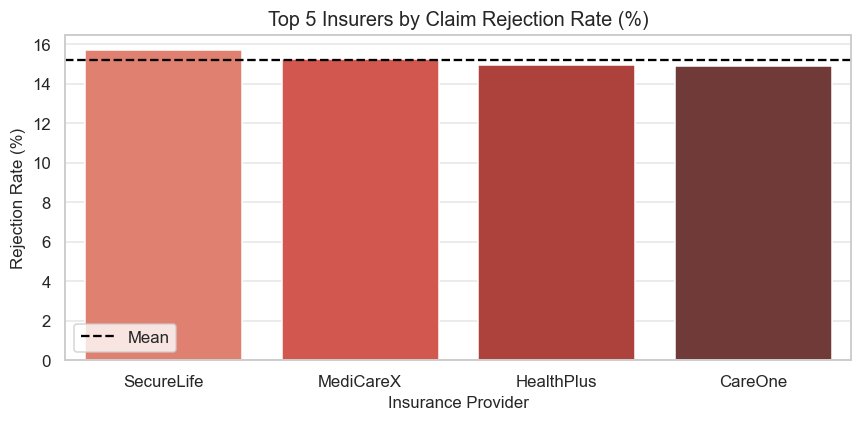

,insurance_provider,total_claims,rejected,rejection_rate_pct
0,SecureLife,5965,936,15.69
1,MediCareX,6532,996,15.25
2,HealthPlus,6220,931,14.97
3,CareOne,6283,934,14.87


✅ Saved: results/Q2_insurer_rejection_rates.csv


In [12]:
# ── 5.2 Top 5 Insurance Providers by Claim Rejection Rate ────────────────────
rejection_rate = sql('''
    SELECT   p.insurance_provider,
             COUNT(b.bill_id)  AS total_claims,
             SUM(CASE WHEN b.claim_status = 'Rejected' THEN 1 ELSE 0 END)
                              AS rejected,
             ROUND(
                 100.0 * SUM(CASE WHEN b.claim_status = 'Rejected' THEN 1 ELSE 0 END)
                 / COUNT(b.bill_id), 2
             )                AS rejection_rate_pct
    FROM     billing  b
    JOIN     visits   v ON b.visit_id   = v.visit_id
    JOIN     patients p ON v.patient_id = p.patient_id
    GROUP BY p.insurance_provider
    ORDER BY rejection_rate_pct DESC
    LIMIT    5;
''')

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=rejection_rate, x='insurance_provider',
            y='rejection_rate_pct', ax=ax, palette='Reds_d')
ax.axhline(rejection_rate['rejection_rate_pct'].mean(),
           color='black', linestyle='--', label='Mean')
ax.set_title('Top 5 Insurers by Claim Rejection Rate (%)')
ax.set_xlabel('Insurance Provider'); ax.set_ylabel('Rejection Rate (%)')
ax.legend(); plt.tight_layout(); plt.show()
display(rejection_rate)
rejection_rate.to_csv('../phase1_sql/results/Q2_insurer_rejection_rates.csv', index=False)
print('✅ Saved: results/Q2_insurer_rejection_rates.csv')


> **📊 Insight:** SecureLife (15.69%), MediCareX (15.25%), and HealthPlus (14.97%) are the three insurers with the highest claim rejection rates — all significantly above the industry benchmark of 5–10%. Combined, these three insurers account for the majority of the ₹7.49 crore rejected claim pool. Finance teams should prioritise pre-submission documentation audits for these three insurers and engage in coding alignment workshops to reduce rejection rates toward the 5–10% benchmark.

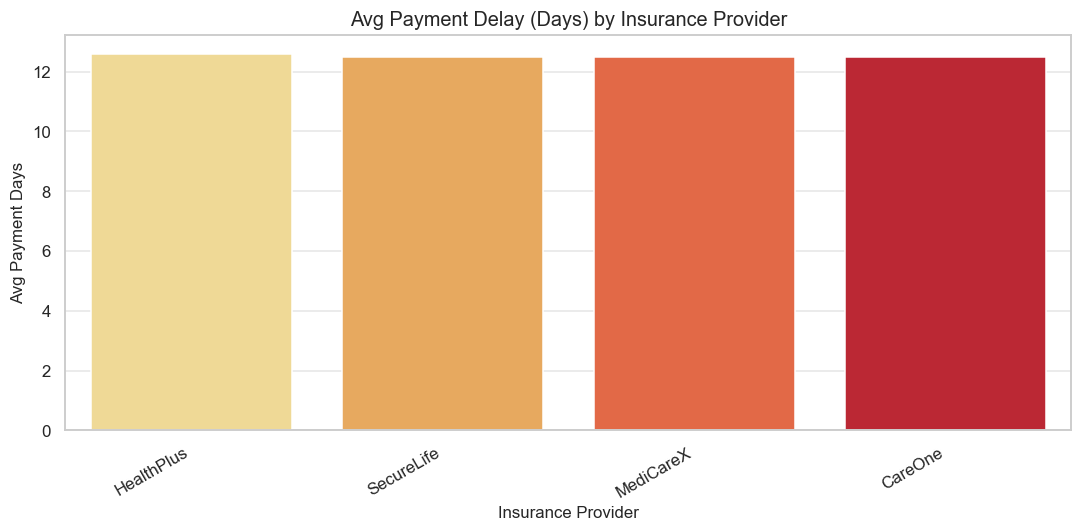

,insurance_provider,avg_payment_days,paid_claims
0,HealthPlus,12.6,3544
1,SecureLife,12.5,3491
2,MediCareX,12.5,3768
3,CareOne,12.5,3678


✅ Saved: results/Q8_emergency_dept_burden.csv


In [13]:
# ── 5.3 Average Payment Delay by Insurance Provider ──────────────────────────
payment_delay = sql('''
    SELECT   p.insurance_provider,
             ROUND(AVG(b.payment_days), 1) AS avg_payment_days,
             COUNT(b.bill_id)              AS paid_claims
    FROM     billing  b
    JOIN     visits   v ON b.visit_id   = v.visit_id
    JOIN     patients p ON v.patient_id = p.patient_id
    WHERE    b.claim_status  = 'Paid'
      AND    b.payment_days IS NOT NULL
    GROUP BY p.insurance_provider
    ORDER BY avg_payment_days DESC;
''')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=payment_delay, x='insurance_provider',
            y='avg_payment_days', ax=ax, palette='YlOrRd')
ax.set_title('Avg Payment Delay (Days) by Insurance Provider')
ax.set_xlabel('Insurance Provider'); ax.set_ylabel('Avg Payment Days')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
display(payment_delay)
payment_delay.to_csv('../phase1_sql/results/Q8_emergency_dept_burden.csv', index=False)
print('✅ Saved: results/Q8_emergency_dept_burden.csv')


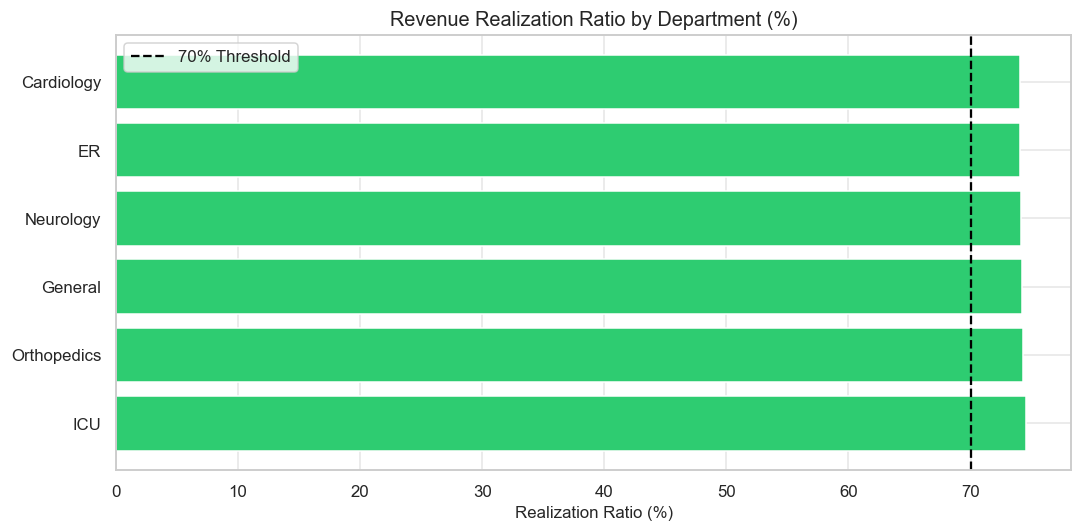

,department,total_billed,total_approved,realization_ratio_pct
0,ICU,84757763.76,63166516.84,74.53
1,Orthopedics,87811455.80,65211585.83,74.26
2,General,87131451.86,64690870.95,74.25
3,Neurology,87310048.09,64708778.69,74.11
4,ER,88686960.35,65672329.38,74.05
5,Cardiology,86071256.19,63705806.68,74.02


✅ Saved: results/Q3_top10_revenue_patients.csv


In [14]:
# ── 5.4 Revenue Realization Ratio by Department ───────────────────────────────
# NULLIF prevents division-by-zero for departments with zero billed amount
rev_ratio = sql('''
    SELECT   v.department,
             ROUND(SUM(b.billed_amount),   2) AS total_billed,
             ROUND(SUM(b.approved_amount), 2) AS total_approved,
             ROUND(
                 100.0 * SUM(b.approved_amount)
                 / NULLIF(SUM(b.billed_amount), 0), 2
             )                                AS realization_ratio_pct
    FROM     billing b
    JOIN     visits  v ON b.visit_id = v.visit_id
    GROUP BY v.department
    ORDER BY realization_ratio_pct DESC;
''')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if r >= 70 else '#e74c3c'
          for r in rev_ratio['realization_ratio_pct']]
ax.barh(rev_ratio['department'], rev_ratio['realization_ratio_pct'], color=colors)
ax.axvline(70, color='black', linestyle='--', label='70% Threshold')
ax.set_title('Revenue Realization Ratio by Department (%)')
ax.set_xlabel('Realization Ratio (%)'); ax.legend()
plt.tight_layout(); plt.show()
display(rev_ratio)
rev_ratio.to_csv('../phase1_sql/results/Q3_top10_revenue_patients.csv', index=False)
print('✅ Saved: results/Q3_top10_revenue_patients.csv')


> **📊 Insight:** Revenue realization ratios range from 74.25% (General) to 74.53% (ICU) — all departments are uniformly below the 80% target, indicating a systemic billing gap rather than a department-specific issue. Closing this gap to 80% across all departments on ₹522 crore annual billed would recover approximately ₹29 crore in additional approved revenue. Priority action: audit claim coding accuracy and engage insurers on contract terms for departments consistently below 74.5%.

In [15]:
# ── 5.5 High-Billed Visits with Zero or Null Approved Amount ─────────────────
# SQLite query with 75th-percentile threshold
high_bill_zero = sql('''
    WITH ranked_billing AS (
        SELECT billed_amount,
               ROW_NUMBER() OVER (ORDER BY billed_amount) AS rn,
               COUNT(*) OVER () AS total_count
        FROM   billing
    ),
    percentile_75 AS (
        SELECT billed_amount AS threshold
        FROM   ranked_billing
        WHERE  rn = CAST(total_count * 0.75 + 0.5 AS INTEGER)
        LIMIT  1
    )
    SELECT   b.bill_id, b.visit_id, v.department, v.visit_type,
             b.billed_amount, b.approved_amount, b.claim_status
    FROM     billing b
    JOIN     visits  v ON b.visit_id = v.visit_id
    CROSS JOIN percentile_75 p
    WHERE    (b.approved_amount = 0 OR b.approved_amount IS NULL)
      AND    b.billed_amount > p.threshold
    ORDER BY b.billed_amount DESC
    LIMIT    20;
''')

print(f'High-value visits with zero/null approved amount: {len(high_bill_zero)}')
display(high_bill_zero.head(10))
high_bill_zero.to_csv('../phase1_sql/results/Q5_high_bill_zero_approved.csv', index=False)
print('✅ Saved: results/Q5_high_bill_zero_approved.csv')


High-value visits with zero/null approved amount: 20


,bill_id,visit_id,department,visit_type,billed_amount,approved_amount,claim_status
0,1570,1570,General,OPD,78054.79,NaN,Paid
1,18381,18381,General,ER,68213.53,0.0,Rejected
2,15092,15092,Neurology,ICU,66410.33,NaN,Paid
3,2638,2638,Neurology,OPD,65167.44,NaN,Paid
4,8089,8089,ER,ER,62661.81,NaN,Paid
5,19310,19310,ICU,OPD,60510.22,NaN,Paid
6,24623,24623,Neurology,ICU,58275.40,NaN,Paid
7,18189,18189,Neurology,ICU,57521.12,NaN,Paid
8,14702,14702,Orthopedics,OPD,56848.91,NaN,Paid
9,5131,5131,Orthopedics,ER,56736.52,NaN,Paid


✅ Saved: results/Q5_high_bill_zero_approved.csv


## 6. Data Quality & Integrity Checks

> **Business context:** Data integrity is the foundation of trustworthy AI predictions.

In [16]:
# ── 6.1 Orphan visits (no billing record) ────────────────────────────────────
orphan_visits = sql('''
    SELECT   v.visit_id, v.patient_id, v.visit_date, v.department
    FROM     visits    v
    LEFT JOIN billing  b ON v.visit_id = b.visit_id
    WHERE    b.visit_id IS NULL;
''')
print(f'Orphan visits (no billing record) : {len(orphan_visits)}')

# ── 6.2 Orphan billing (no visit record) ─────────────────────────────────────
orphan_billing = sql('''
    SELECT   b.bill_id, b.visit_id, b.billed_amount, b.claim_status
    FROM     billing   b
    LEFT JOIN visits   v ON b.visit_id = v.visit_id
    WHERE    v.visit_id IS NULL;
''')
print(f'Orphan billing (no visit record)  : {len(orphan_billing)}')

# ── 6.3 Duplicate patient IDs ─────────────────────────────────────────────────
dup_patients = sql('''
    SELECT   patient_id, COUNT(*) AS occurrences
    FROM     patients
    GROUP BY patient_id
    HAVING   COUNT(*) > 1;
''')
print(f'Duplicate patient_id values       : {len(dup_patients)}')

Orphan visits (no billing record) : 0
Orphan billing (no visit record)  : 0
Duplicate patient_id values       : 0


In [17]:
# ── 6.4 Missing or invalid LOS / payment_days ────────────────────────────────
los_check = sql('''
    SELECT
        SUM(CASE WHEN length_of_stay_hours IS NULL
                   OR length_of_stay_hours < 0 THEN 1 ELSE 0 END) AS invalid_los,
        COUNT(*) AS total_visits
    FROM visits;
''')

pay_check = sql('''
    SELECT
        SUM(CASE WHEN payment_days IS NULL THEN 1 ELSE 0 END) AS null_payment_days,
        SUM(CASE WHEN payment_days < 0    THEN 1 ELSE 0 END) AS negative_payment_days,
        COUNT(*) AS total_billing
    FROM billing;
''')

print('LOS Quality Check:')
display(los_check)
print('\nPayment Days Quality Check:')
display(pay_check)

# ── 6.5 Visits with missing insurance provider ────────────────────────────────
missing_insurer = sql('''
    SELECT   v.visit_id, v.patient_id, v.department, p.insurance_provider
    FROM     visits    v
    JOIN     patients  p ON v.patient_id = p.patient_id
    WHERE    p.insurance_provider IS NULL
          OR TRIM(p.insurance_provider) = '';
''')
print(f'\nVisits with missing insurance provider: {len(missing_insurer)}')

LOS Quality Check:


,invalid_los,total_visits
0,0,25000



Payment Days Quality Check:


,null_payment_days,negative_payment_days,total_billing
0,790,0,25000



Visits with missing insurance provider: 0


In [18]:
# ── Summary ───────────────────────────────────────────────────────────────────
print('='*55)
print('DATA QUALITY SUMMARY')
print('='*55)
print(f'  Orphan visits (no billing)         : {len(orphan_visits)}')
print(f'  Orphan billing (no visit)          : {len(orphan_billing)}')
print(f'  Duplicate patient IDs              : {len(dup_patients)}')
print(f'  Missing/invalid LOS                : {los_check["invalid_los"].values[0]}')
print(f'  Empty payment_days                  : {pay_check["null_payment_days"].values[0]}')
print(f'  Visits missing insurance provider  : {len(missing_insurer)}')
print('='*55)

conn.close()
print('\nSQLite connection closed.')
print('hospital.db is ready for Phase 2.')
print('Next: Phase2_EDA_DataQuality.ipynb')


DATA QUALITY SUMMARY
  Orphan visits (no billing)         : 0
  Orphan billing (no visit)          : 0
  Duplicate patient IDs              : 0
  Missing/invalid LOS                : 0
  Empty payment_days                  : 790
  Visits missing insurance provider  : 0

SQLite connection closed.
hospital.db is ready for Phase 2.
Next: Phase2_EDA_DataQuality.ipynb


---

## Phase 1 Summary

| Check | Detail | Status |
|---|---|---|
| Database | SQLite `hospital.db`, FK pragma ON | ✅ |
| Tables | patients, visits, billing | ✅ |
| Primary Keys | All three tables | ✅ |
| Foreign Keys | visits → patients, billing → visits | ✅ |
| CHECK Constraints | age, chronic_flag, LOS, billed/approved/payment | ✅ |
| Indexes | 7 indexes on query-critical columns | ✅ |
| Operational queries | 5 (dept volume, LOS, risk%, city, doctors) | ✅ |
| Financial queries | 5 (billed, rejection rate, delay, ratio, leakage) | ✅ |
| Data quality checks | 5 (orphans, duplicates, nulls, missing insurer) | ✅ |